# Credit Card Fraud Detection

## Project Overview

This project focuses on detecting fraudulent credit card transactions using machine learning.

The dataset contains real-world credit card transactions with a highly imbalanced target variable, where fraudulent transactions represent only a very small portion of all transactions.

The project focuses on exploratory data analysis, class imbalance handling, machine learning model development, evaluation, and interpretation.

## Objectives

- Analyze the distribution of fraudulent and legitimate transactions
- Perform exploratory data analysis
- Analyze transaction amount and time patterns
- Understand the challenges of class imbalance
- Apply an appropriate imbalance-handling technique
- Train classification models
- Evaluate models using Precision, Recall, F1-score, and ROC-AUC
- Analyze important features
- Discuss how the fraud detection system could scale to high transaction volumes

## Technologies Used

- Python
- Pandas
- NumPy
- Scikit-learn
- Imbalanced-learn
- Matplotlib
- Seaborn
- Jupyter Notebook

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    roc_curve,
    confusion_matrix,
    classification_report
)

In [5]:
import pandas as pd

df = pd.read_csv("../dataset/creditcard.csv")

print("Dataset loaded successfully!")
print("Shape:", df.shape)

Dataset loaded successfully!
Shape: (284807, 31)


In [6]:
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [7]:
# Basic dataset inspection

print("Dataset Shape:", df.shape)

print("\nFirst 5 rows:")
display(df.head())

print("\nDataset Information:")
df.info()

print("\nMissing Values:")
print(df.isnull().sum().sum())

print("\nDuplicate Rows:")
print(df.duplicated().sum())

print("\nStatistical Summary:")
display(df.describe())

Dataset Shape: (284807, 31)

First 5 rows:


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0



Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  f

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.000000,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,...,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000,284807.000000
mean,94813.859575,1.175161e-15,3.384974e-16,-1.379537e-15,2.094852e-15,1.021879e-15,1.494498e-15,-5.620335e-16,1.149614e-16,-2.414189e-15,...,1.628620e-16,-3.576577e-16,2.618565e-16,4.473914e-15,5.109395e-16,1.686100e-15,-3.661401e-16,-1.227452e-16,88.349619,0.001727
std,47488.145955,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,...,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,250.120109,0.041527
min,0.000000,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,...,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000,0.000000
25%,54201.500000,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,...,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,5.600000,0.000000
50%,84692.000000,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,...,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,22.000000,0.000000
75%,139320.500000,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,...,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,77.165000,0.000000
max,172792.000000,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,...,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,25691.160000,1.000000


Transaction Counts:
Class
0    284315
1       492
Name: count, dtype: int64

Transaction Percentages:
Class
0    99.8273
1     0.1727
Name: proportion, dtype: float64


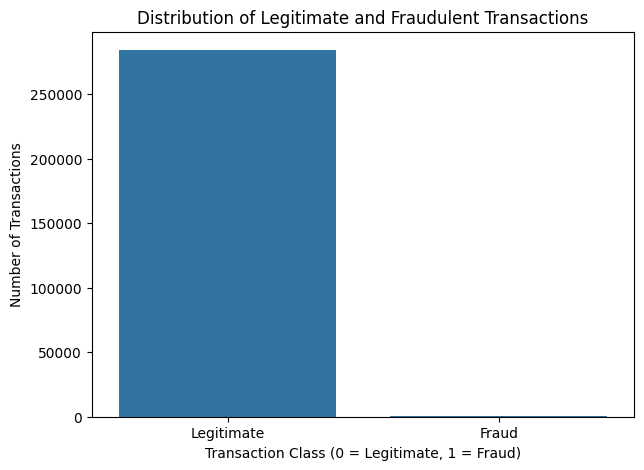

In [8]:
# Class distribution

class_counts = df["Class"].value_counts()

print("Transaction Counts:")
print(class_counts)

print("\nTransaction Percentages:")
print((df["Class"].value_counts(normalize=True) * 100).round(4))

# Visualization
plt.figure(figsize=(7, 5))
sns.countplot(x="Class", data=df)

plt.title("Distribution of Legitimate and Fraudulent Transactions")
plt.xlabel("Transaction Class (0 = Legitimate, 1 = Fraud)")
plt.ylabel("Number of Transactions")
plt.xticks([0, 1], ["Legitimate", "Fraud"])
plt.show()

Average transaction amount by class:
Class
0     88.291022
1    122.211321
Name: Amount, dtype: float64

Median transaction amount by class:
Class
0    22.00
1     9.25
Name: Amount, dtype: float64


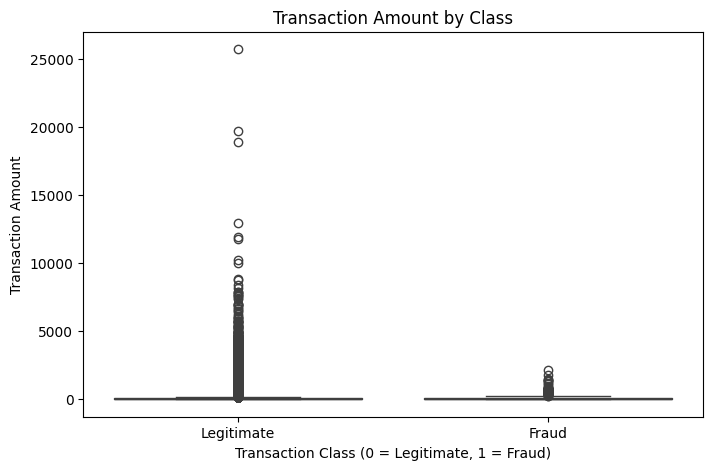

In [9]:
# Transaction Amount Analysis

print("Average transaction amount by class:")
print(df.groupby("Class")["Amount"].mean())

print("\nMedian transaction amount by class:")
print(df.groupby("Class")["Amount"].median())

# Boxplot
plt.figure(figsize=(8, 5))
sns.boxplot(x="Class", y="Amount", data=df)

plt.title("Transaction Amount by Class")
plt.xlabel("Transaction Class (0 = Legitimate, 1 = Fraud)")
plt.ylabel("Transaction Amount")
plt.xticks([0, 1], ["Legitimate", "Fraud"])
plt.show()

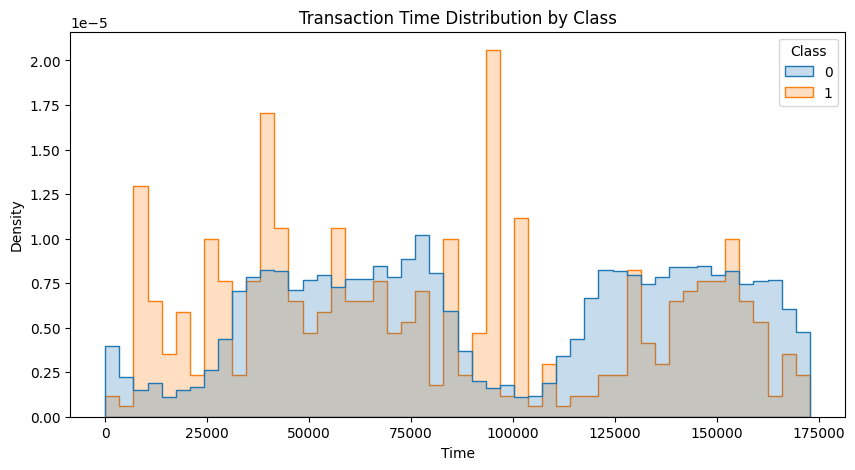

In [10]:
# Transaction Time Analysis

plt.figure(figsize=(10, 5))
sns.histplot(
    data=df,
    x="Time",
    hue="Class",
    bins=50,
    element="step",
    stat="density",
    common_norm=False
)

plt.title("Transaction Time Distribution by Class")
plt.xlabel("Time")
plt.ylabel("Density")
plt.show()

In [11]:
# Correlation with target variable

correlations = df.corr(numeric_only=True)["Class"].sort_values()

print("Features most negatively correlated with Class:")
display(correlations.head(5))

print("\nFeatures most positively correlated with Class:")
display(correlations.tail(6))

Features most negatively correlated with Class:


V17   -0.326481
V14   -0.302544
V12   -0.260593
V10   -0.216883
V16   -0.196539
Name: Class, dtype: float64


Features most positively correlated with Class:


V19      0.034783
V21      0.040413
V2       0.091289
V4       0.133447
V11      0.154876
Class    1.000000
Name: Class, dtype: float64

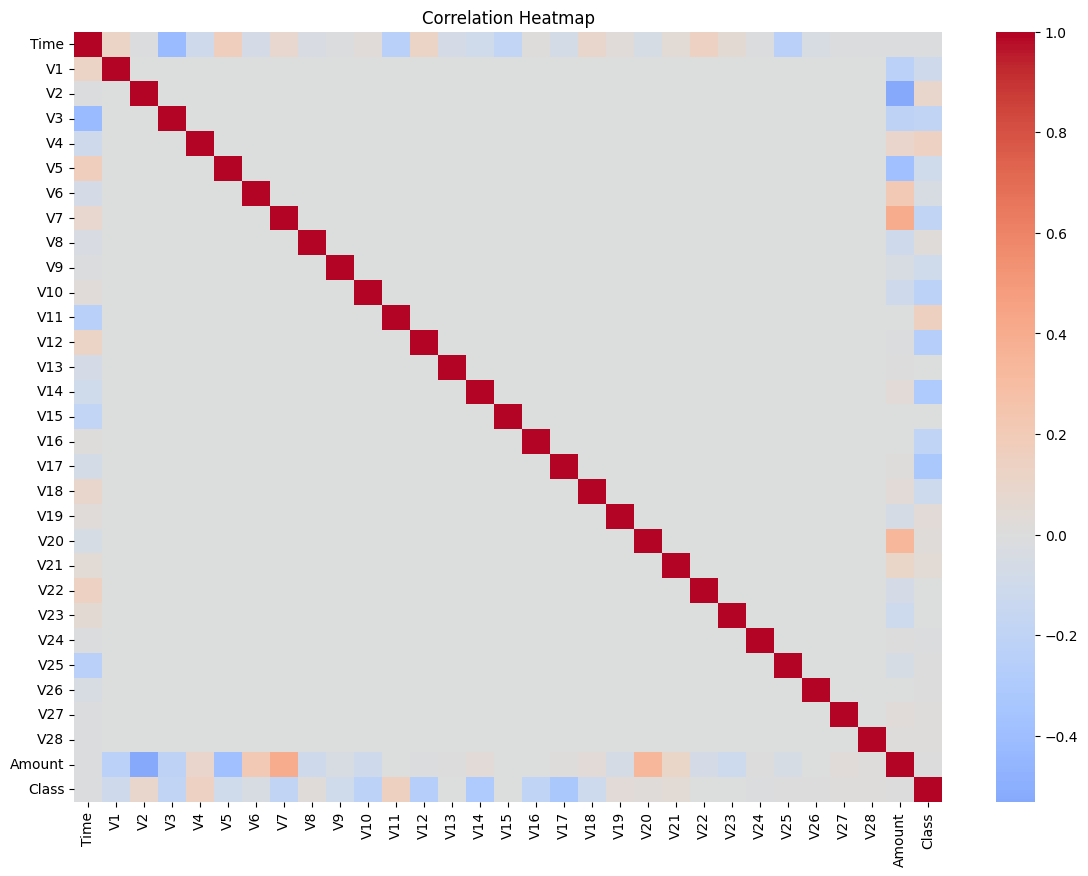

In [12]:
# Correlation Heatmap

plt.figure(figsize=(14, 10))

sns.heatmap(
    df.corr(numeric_only=True),
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Heatmap")
plt.show()

In [13]:
# Separate features and target

X = df.drop("Class", axis=1)
y = df["Class"]

print("Features shape:", X.shape)
print("Target shape:", y.shape)

print("\nTarget distribution:")
print(y.value_counts())

Features shape: (284807, 30)
Target shape: (284807,)

Target distribution:
Class
0    284315
1       492
Name: count, dtype: int64


In [14]:
# Train-Test Split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

print("\nTraining class distribution:")
print(y_train.value_counts())

print("\nTesting class distribution:")
print(y_test.value_counts())

Training data: (227845, 30)
Testing data: (56962, 30)

Training class distribution:
Class
0    227451
1       394
Name: count, dtype: int64

Testing class distribution:
Class
0    56864
1       98
Name: count, dtype: int64


In [15]:
# Feature Scaling

scaler = StandardScaler()

X_train = X_train.copy()
X_test = X_test.copy()

X_train[["Time", "Amount"]] = scaler.fit_transform(
    X_train[["Time", "Amount"]]
)

X_test[["Time", "Amount"]] = scaler.transform(
    X_test[["Time", "Amount"]]
)

print("Feature scaling completed successfully.")

Feature scaling completed successfully.


In [16]:
# Check class imbalance

print("Before handling imbalance:")
print(y_train.value_counts())

print("\nFraud percentage in training data:")
print((y_train.value_counts(normalize=True) * 100).round(4))

Before handling imbalance:
Class
0    227451
1       394
Name: count, dtype: int64

Fraud percentage in training data:
Class
0    99.8271
1     0.1729
Name: proportion, dtype: float64


In [17]:
# Logistic Regression with class balancing

logistic_model = LogisticRegression(
    class_weight="balanced",
    max_iter=1000,
    random_state=42
)

logistic_model.fit(X_train, y_train)

print("Logistic Regression model trained successfully.")

Logistic Regression model trained successfully.


In [18]:
# Random Forest with class balancing

rf_model = RandomForestClassifier(
    n_estimators=100,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

print("Random Forest model trained successfully.")

Random Forest model trained successfully.


In [19]:
# Predictions

y_pred_lr = logistic_model.predict(X_test)
y_prob_lr = logistic_model.predict_proba(X_test)[:, 1]

y_pred_rf = rf_model.predict(X_test)
y_prob_rf = rf_model.predict_proba(X_test)[:, 1]

print("Predictions generated successfully.")

Predictions generated successfully.


In [20]:
# Logistic Regression Evaluation

print("LOGISTIC REGRESSION")
print("-" * 40)

print("Accuracy :", accuracy_score(y_test, y_pred_lr))
print("Precision:", precision_score(y_test, y_pred_lr))
print("Recall   :", recall_score(y_test, y_pred_lr))
print("F1-Score :", f1_score(y_test, y_pred_lr))
print("ROC-AUC  :", roc_auc_score(y_test, y_prob_lr))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_lr))

LOGISTIC REGRESSION
----------------------------------------
Accuracy : 0.9755275446789088
Precision: 0.06097560975609756
Recall   : 0.9183673469387755
F1-Score : 0.11435832274459974
ROC-AUC  : 0.9721687370080279

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.98      0.99     56864
           1       0.06      0.92      0.11        98

    accuracy                           0.98     56962
   macro avg       0.53      0.95      0.55     56962
weighted avg       1.00      0.98      0.99     56962



In [21]:
# Random Forest Evaluation

print("RANDOM FOREST")
print("-" * 40)

print("Accuracy :", accuracy_score(y_test, y_pred_rf))
print("Precision:", precision_score(y_test, y_pred_rf))
print("Recall   :", recall_score(y_test, y_pred_rf))
print("F1-Score :", f1_score(y_test, y_pred_rf))
print("ROC-AUC  :", roc_auc_score(y_test, y_prob_rf))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf))

RANDOM FOREST
----------------------------------------
Accuracy : 0.9995084442259752
Precision: 0.9605263157894737
Recall   : 0.7448979591836735
F1-Score : 0.8390804597701149
ROC-AUC  : 0.952908497036969

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.96      0.74      0.84        98

    accuracy                           1.00     56962
   macro avg       0.98      0.87      0.92     56962
weighted avg       1.00      1.00      1.00     56962



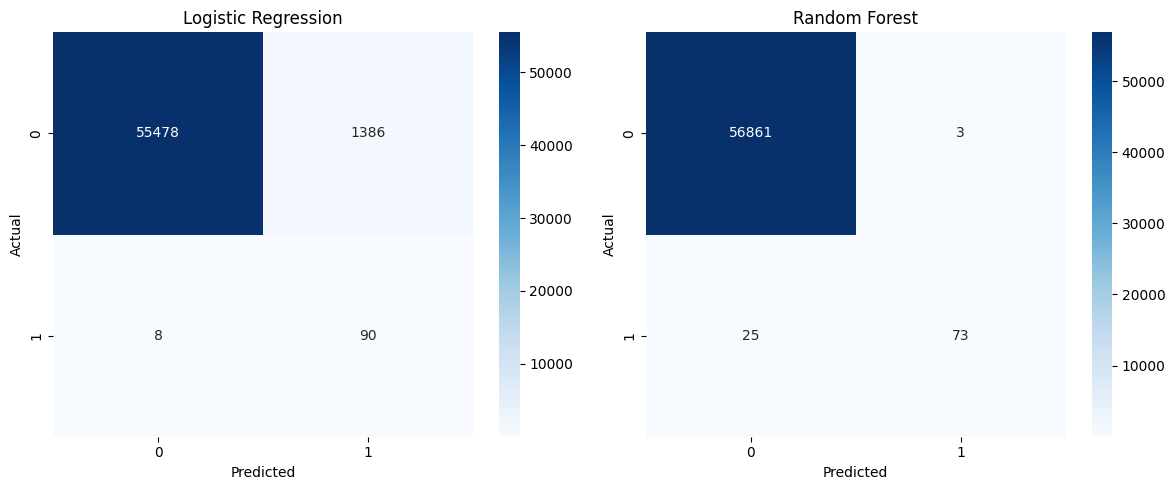

In [22]:
# Confusion Matrices

cm_lr = confusion_matrix(y_test, y_pred_lr)
cm_rf = confusion_matrix(y_test, y_pred_rf)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.heatmap(
    cm_lr,
    annot=True,
    fmt="d",
    cmap="Blues",
    ax=axes[0]
)
axes[0].set_title("Logistic Regression")
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("Actual")

sns.heatmap(
    cm_rf,
    annot=True,
    fmt="d",
    cmap="Blues",
    ax=axes[1]
)
axes[1].set_title("Random Forest")
axes[1].set_xlabel("Predicted")
axes[1].set_ylabel("Actual")

plt.tight_layout()
plt.show()

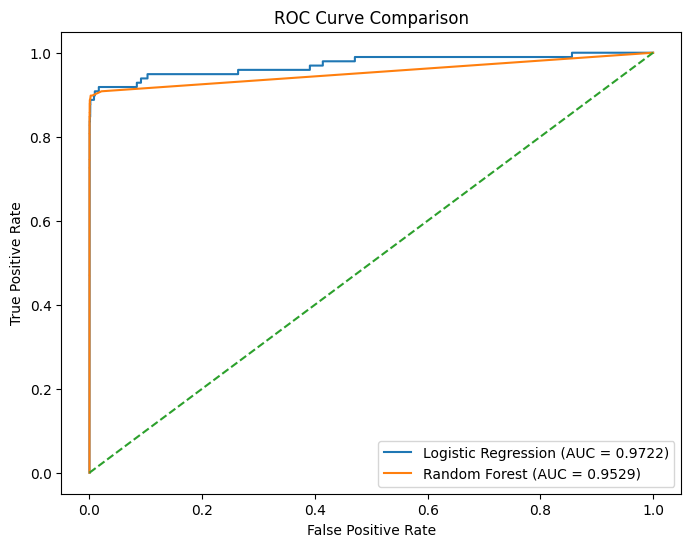

In [23]:
# ROC Curves

fpr_lr, tpr_lr, _ = roc_curve(y_test, y_prob_lr)
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)

plt.figure(figsize=(8, 6))

plt.plot(
    fpr_lr,
    tpr_lr,
    label=f"Logistic Regression (AUC = {roc_auc_score(y_test, y_prob_lr):.4f})"
)

plt.plot(
    fpr_rf,
    tpr_rf,
    label=f"Random Forest (AUC = {roc_auc_score(y_test, y_prob_rf):.4f})"
)

plt.plot([0, 1], [0, 1], linestyle="--")

plt.title("ROC Curve Comparison")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()

In [24]:
# Model Performance Comparison

results = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest"],
    "Accuracy": [
        accuracy_score(y_test, y_pred_lr),
        accuracy_score(y_test, y_pred_rf)
    ],
    "Precision": [
        precision_score(y_test, y_pred_lr),
        precision_score(y_test, y_pred_rf)
    ],
    "Recall": [
        recall_score(y_test, y_pred_lr),
        recall_score(y_test, y_pred_rf)
    ],
    "F1-Score": [
        f1_score(y_test, y_pred_lr),
        f1_score(y_test, y_pred_rf)
    ],
    "ROC-AUC": [
        roc_auc_score(y_test, y_prob_lr),
        roc_auc_score(y_test, y_prob_rf)
    ]
})

display(results.round(4))

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Logistic Regression,0.9755,0.0610,0.9184,0.1144,0.9722
1,Random Forest,0.9995,0.9605,0.7449,0.8391,0.9529


In [25]:
# Feature Importance

feature_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": rf_model.feature_importances_
}).sort_values(
    by="Importance",
    ascending=False
)

display(feature_importance.head(15))

,Feature,Importance
14,V14,0.179857
10,V10,0.115442
12,V12,0.096206
4,V4,0.095646
17,V17,0.095113
3,V3,0.068669
11,V11,0.056112
16,V16,0.040303
2,V2,0.036265
9,V9,0.026888


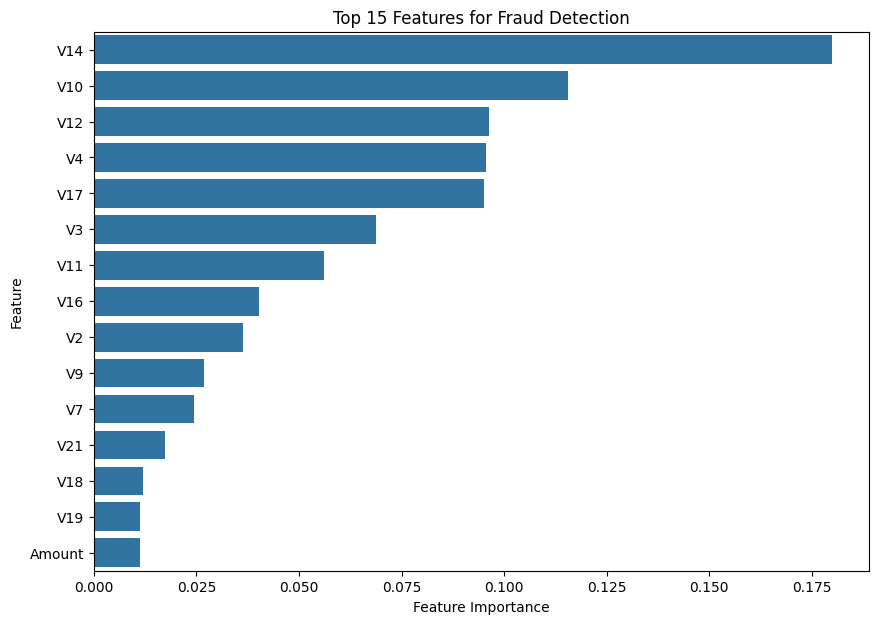

In [26]:
# Top 15 Important Features

top_features = feature_importance.head(15)

plt.figure(figsize=(10, 7))

sns.barplot(
    data=top_features,
    x="Importance",
    y="Feature"
)

plt.title("Top 15 Features for Fraud Detection")
plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.show()

In [27]:
# Save model comparison results

results.to_csv(
    "../output/fraud_model_comparison.csv",
    index=False
)

feature_importance.to_csv(
    "../output/fraud_feature_importance.csv",
    index=False
)

print("Output files saved successfully!")

Output files saved successfully!


## Key Findings

The fraud detection models were evaluated using Accuracy, Precision, Recall, F1-Score, and ROC-AUC.

The analysis focuses particularly on Recall and F1-Score because correctly identifying fraudulent transactions is important in an imbalanced classification problem.

In [28]:
# Display final model results

display(results.round(4))

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Logistic Regression,0.9755,0.0610,0.9184,0.1144,0.9722
1,Random Forest,0.9995,0.9605,0.7449,0.8391,0.9529


In [29]:
# Extract model metrics

for _, row in results.iterrows():
    print(f"\n{row['Model']}")
    print(f"Precision: {row['Precision']:.4f}")
    print(f"Recall:    {row['Recall']:.4f}")
    print(f"F1-Score:  {row['F1-Score']:.4f}")
    print(f"ROC-AUC:   {row['ROC-AUC']:.4f}")


Logistic Regression
Precision: 0.0610
Recall:    0.9184
F1-Score:  0.1144
ROC-AUC:   0.9722

Random Forest
Precision: 0.9605
Recall:    0.7449
F1-Score:  0.8391
ROC-AUC:   0.9529


In [30]:
# Detailed fraud statistics

fraud_df = df[df["Class"] == 1]

print("Number of fraudulent transactions:", len(fraud_df))
print("Average fraud transaction amount:", round(fraud_df["Amount"].mean(), 2))
print("Median fraud transaction amount:", round(fraud_df["Amount"].median(), 2))
print("Maximum fraud transaction amount:", round(fraud_df["Amount"].max(), 2))
print("Minimum fraud transaction amount:", round(fraud_df["Amount"].min(), 2))

Number of fraudulent transactions: 492
Average fraud transaction amount: 122.21
Median fraud transaction amount: 9.25
Maximum fraud transaction amount: 2125.87
Minimum fraud transaction amount: 0.0


In [31]:
# Top 10 features

top_10_features = feature_importance.head(10).reset_index(drop=True)

display(top_10_features)

,Feature,Importance
0,V14,0.179857
1,V10,0.115442
2,V12,0.096206
3,V4,0.095646
4,V17,0.095113
5,V3,0.068669
6,V11,0.056112
7,V16,0.040303
8,V2,0.036265
9,V9,0.026888


## Conclusion

This project developed a machine learning-based credit card fraud detection system using transaction data.

The dataset was highly imbalanced, with fraudulent transactions representing only a small proportion of all transactions. Exploratory data analysis was performed to understand transaction patterns, class distribution, transaction amounts, time patterns, and feature correlations.

Logistic Regression and Random Forest models were trained using class weighting to address the class imbalance. The models were evaluated using Precision, Recall, F1-Score, and ROC-AUC along with confusion matrices and ROC curves.

The results demonstrate that machine learning can be used to identify potentially fraudulent transactions while providing measurable performance indicators for evaluating the detection system.

For a real-world deployment, the system could be integrated with a transaction monitoring pipeline and continuously updated using new transaction data. Threshold tuning, real-time processing, model monitoring, and periodic retraining could further improve the system's ability to adapt to changing fraud patterns.

## Business Recommendations

1. Use machine learning models to flag potentially fraudulent transactions for further investigation.

2. Monitor Recall and Precision continuously because both missed fraud and false alerts can have business consequences.

3. Use transaction amount, time, and model-identified important features as part of fraud monitoring.

4. Apply threshold tuning based on the business cost of false positives and false negatives.

5. Retrain the model periodically because fraud patterns can change over time.

6. For high-volume systems, deploy the model through a real-time transaction monitoring pipeline with automated alerts and human review for suspicious cases.